![Logo](img/ITQ.png)
## Nombre: Elvis Pachacama
### Fecha: 08/06/2026

### Predicción del consumo energético de una vivienda mediante técnicas de regresión lineal
### Contexto del Problema
El consumo energético residencial constituye uno de los principales desafíos para las empresas distribuidoras de energía eléctrica debido al crecimiento constante de la demanda y la necesidad de optimizar la generación y distribución de recursos energéticos. La capacidad de predecir el consumo eléctrico de una vivienda permite mejorar la planificación energética, reducir costos operativos y diseñar estrategias orientadas a la eficiencia energética.

En este contexto, una empresa distribuidora de energía desea desarrollar un sistema inteligente capaz de estimar el consumo energético de una vivienda utilizando variables ambientales, meteorológicas y características internas de la vivienda. Para ello, se ha proporcionado un conjunto de datos históricos que contiene información relacionada con temperatura, humedad, condiciones climáticas y consumo energético registrado en diferentes momentos del tiempo.

Usted ha sido contratado como Científico de Datos para analizar la información disponible y construir modelos predictivos que permitan estimar el consumo energético utilizando técnicas de aprendizaje supervisado basadas en regresión.
### Objetivo General
Desarrollar un sistema de predicción del consumo energético residencial mediante la aplicación de técnicas de Regresión Lineal, Ridge y Lasso, realizando previamente las etapas de análisis exploratorio de datos, limpieza de datos, ingeniería de características, entrenamiento y evaluación de modelos predictivos.
### Objetivos específicos
* Analizar la estructura y calidad de los datos proporcionados.
* Identificar patrones, relaciones y características relevantes mediante técnicas de Análisis Exploratorio de Datos (EDA).
* Aplicar procedimientos de limpieza y preparación de datos.
* Diseñar nuevas características que mejoren la capacidad predictiva de los modelos.
* Implementar modelos de Regresión Lineal, Ridge y Lasso.
* Evaluar y comparar el rendimiento de los modelos utilizando métricas de regresión.
* Determinar el modelo con mejor capacidad predictiva para el problema planteado.
### Dataset a utilizar
Utilizar el dataset:

Appliances Energy Prediction Dataset

<a href="https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction">Descargar DataSet</a>

Variables principales:

* Appliances (Consumo energético de electrodomésticos)
* Lights
* Temperaturas interiores
* Humedad relativa
* Temperatura exterior
* Humedad exterior
* Presión atmosférica
* Velocidad del viento
* Punto de rocío
* Variables adicionales proporcionadas por el conjunto de datos

## Desarrollo de la Actividad
#### Fase 1. Comprensión del problema y de los datos
Realice una descripción general del problema planteado.

Analice el conjunto de datos y responda:

* ¿Cuántos registros posee el dataset?
* ¿Cuántas variables contiene?
* ¿Qué tipos de datos existen?
* ¿Cuál será la variable objetivo del modelo?
* ¿Qué variables podrían influir en el consumo energético?

Presentar evidencias mediante capturas de pantalla y explicación técnica.

# cripción general del problema:El problema planteado consiste en predecir el consumo de energía en un entorno residencial utilizando datos recolectados por sensores de temperatura y humedad en diferentes habitaciones junto con información meteorológica exterior

##### El objetivo principal es construir un modelo de regresión capaz de estimar este gasto energético para optimizar el uso de los recursos en el hogarAnálisis del conjunto de dato

##### ¿Cuántos registros posee el dataset?El conjunto de datos posee 19735 registros o filas en total correspondientes a las mediciones recolectadas cada 10 minutos durante un periodo de aproximadamente cuatro meses

##### ¿Cuántas variables contiene?El dataset contiene originalmente 29 variables o columnas que incluyen las mediciones ambientales internas externas y los datos de consumo de energía

##### ¿Qué tipos de datos existen?Existen principalmente tipos de datos numéricos decimales float64 para las temperaturas y humedades relativas datos de tipo entero int64 para el consumo de los electrodomésticos y las luces y un objeto de tipo texto o fecha object para la columna de tiempo date

##### ¿Cuál será la variable objetivo del modelo?La variable objetivo del modelo es Appliances la cual representa el consumo energético en vatios hora Wh de los electrodomésticos de la vivienda y es el valor numérico que buscamos predecir

##### ¿Qué variables podrían influir en el consumo energético?Las variables que más podrían influir son las de consumo de luces lights la hora del día por las rutinas diarias de las personas las temperaturas internas de las zonas principales como la cocina o la sala y la diferencia térmica con la temperatura exterior Tout ya que determinan la necesidad de usar sistemas de climatización o calefacción

In [1]:
import joblib
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:


df = pd.read_csv('energydata_complete.csv')

# 1 y 2. Obtener filas y columnas
filas, columnas = df.shape
print(f"¿Cuántos registros posee el dataset?: {filas}")
print(f"¿Cuántas variables contiene?: {columnas}")

# 3. Obtener los tipos de datos
print("\n¿Qué tipos de datos existen?:")
print(df.dtypes)


¿Cuántos registros posee el dataset?: 19735
¿Cuántas variables contiene?: 29

¿Qué tipos de datos existen?:
date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object


## Fase 2. Análisis Exploratorio de Datos (EDA)

Realizar un análisis exploratorio completo del conjunto de datos.

El análisis deberá incluir:

#### 2.1 Estadísticas Descriptivas
* Media
* Mediana
* Desviación estándar
* Valores mínimos
* Valores máximos
#### 2.2 Identificación de Valores Faltantes

Determinar:

* Cantidad de valores faltantes por variable.
* Estrategia utilizada para su tratamiento.
#### 2.3 Distribución de Variables

* Generar histogramas para las principales variables numéricas.

* Interpretar los resultados obtenidos.

#### 2.4 Matriz de Correlación

Construir una matriz de correlación e identificar:

* Variables con correlación positiva fuerte.
* Variables con correlación negativa fuerte.
* Variables con correlación débil.
* Variable con mayor relación respecto al consumo energético.
#### 2.5 Visualizaciones Adicionales

Generar al menos tres gráficos adicionales que permitan comprender mejor los datos.

Ejemplos:

* Boxplots
* Scatterplots
* Pairplots
* Heatmaps

Cada gráfico deberá incluir su respectiva interpretación.

In [3]:
# Generamos las estadísticas descriptivas para todas las variables numéricas
print("Estadísticas Descriptivas del Conjunto de Datos:")
df.describe()


Estadísticas Descriptivas del Conjunto de Datos:


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [4]:
# Contamos cuántos valores nulos o faltantes hay por cada columna
print("Conteo de valores faltantes por variable:")
df.isnull().sum()


Conteo de valores faltantes por variable:


date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

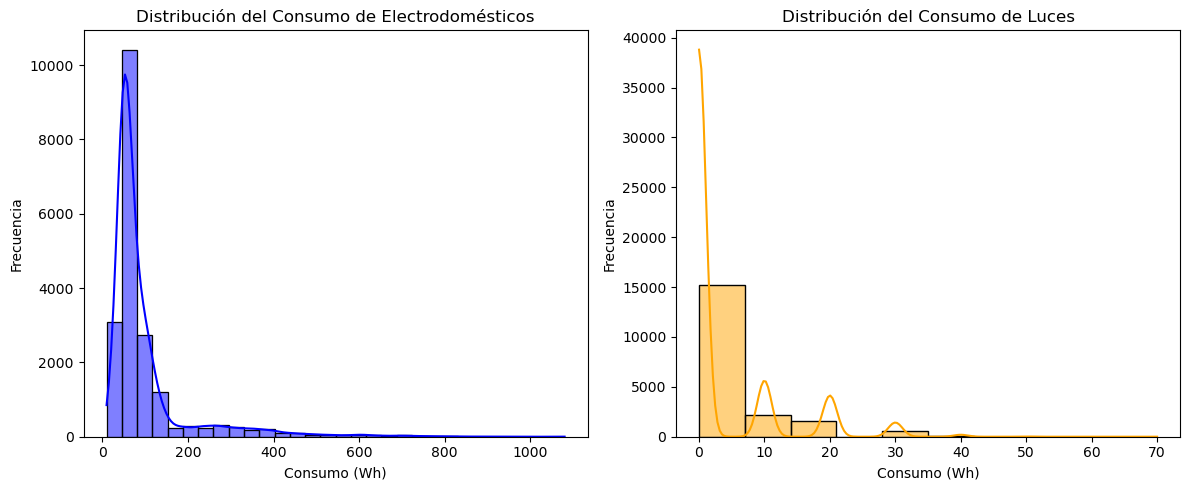

In [5]:


# Configuración del lienzo para los histogramas
plt.figure(figsize=(12, 5))

# Histograma para el consumo de electrodomésticos
plt.subplot(1, 2, 1)
sns.histplot(df['Appliances'], kde=True, color='blue', bins=30)
plt.title('Distribución del Consumo de Electrodomésticos')
plt.xlabel('Consumo (Wh)')
plt.ylabel('Frecuencia')

# Histograma para el consumo de iluminación
plt.subplot(1, 2, 2)
sns.histplot(df['lights'], kde=True, color='orange', bins=10)
plt.title('Distribución del Consumo de Luces')
plt.xlabel('Consumo (Wh)')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()


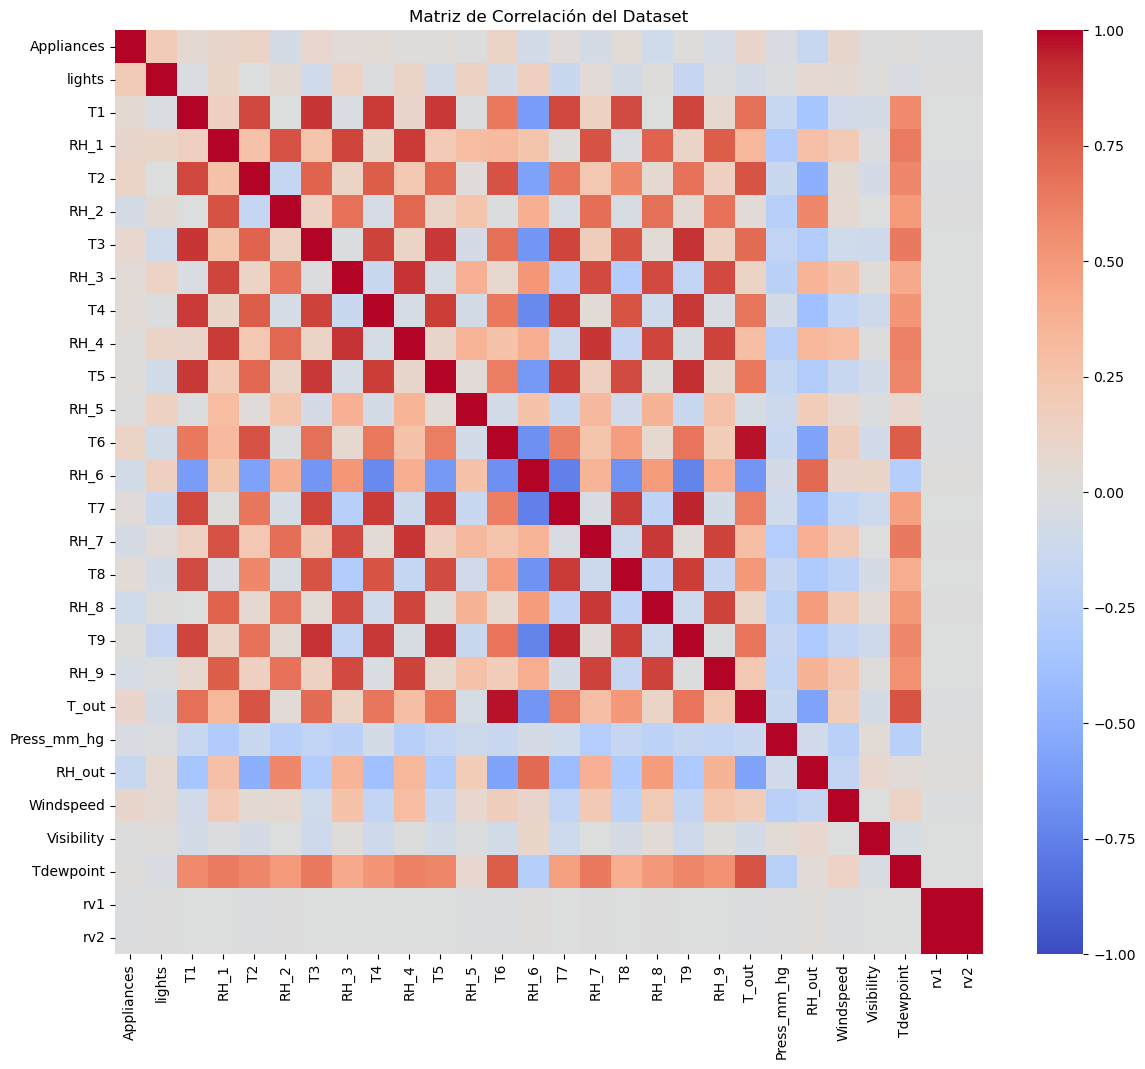

In [6]:
# Filtramos solo las columnas numéricas para calcular la correlación
columnas_numericas = df.select_dtypes(include=['float64', 'int64'])
matriz_corr = columnas_numericas.corr()

# Dibujamos el mapa de calor
plt.figure(figsize=(14, 12))
sns.heatmap(matriz_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación del Dataset')
plt.show()


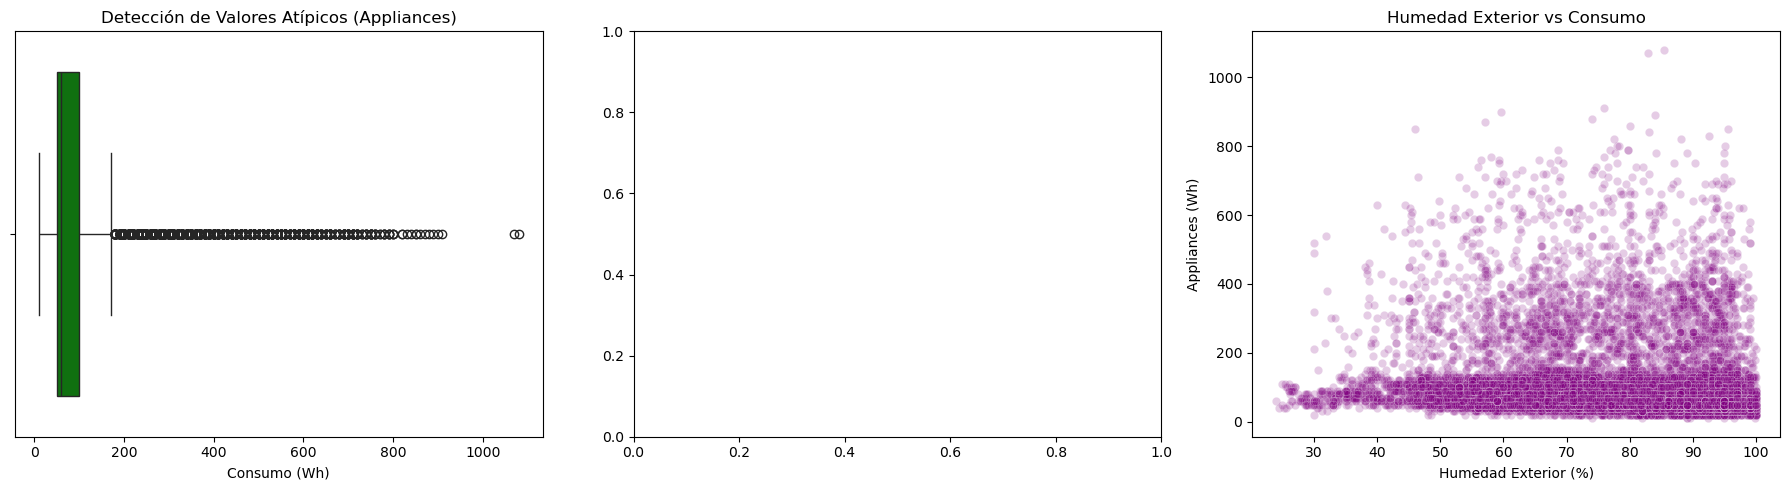

In [7]:
# Creamos tres gráficos adicionales para profundizar en el análisis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#  Diagrama de caja para detectar valores atípicos
sns.boxplot(ax=axes[0], x=df['Appliances'], color='green')
axes[0].set_title('Detección de Valores Atípicos (Appliances)')
axes[0].set_xlabel('Consumo (Wh)')

#  Dispersión entre Temperatura Exterior Tout y Consumo
if 'Tout' in df.columns:
    sns.scatterplot(ax=axes[1], data=df, x='Tout', y='Appliances', alpha=0.2, color='darkred')
    axes[1].set_title('Temperatura Exterior vs Consumo')
    axes[1].set_xlabel('Temperatura Exterior (°C)')
    axes[1].set_ylabel('Appliances (Wh)')

#  Dispersión entre Humedad Exterior RHout y Consumo
if 'RH_out' in df.columns:
    sns.scatterplot(ax=axes[2], data=df, x='RH_out', y='Appliances', alpha=0.2, color='purple')
    axes[2].set_title('Humedad Exterior vs Consumo')
    axes[2].set_xlabel('Humedad Exterior (%)')
    axes[2].set_ylabel('Appliances (Wh)')

plt.tight_layout()
plt.show()


# Fase 3. Limpieza y Preparación de Datos

Realizar las siguientes actividades:

#### 3.1 Tratamiento de Valores Faltantes

Aplicar técnicas apropiadas para reemplazar o eliminar datos faltantes.

Justificar la técnica utilizada.

#### 3.2 Detección y Tratamiento de Valores Atípicos

Aplicar métodos como:

* IQR
* Boxplots
* Z-Score

Explicar los resultados obtenidos.

#### 3.3 Transformación de Variables

Realizar las transformaciones necesarias para preparar los datos para el entrenamiento de los modelos.

###### Para el tratamiento de valores faltantes revisé la base de datos y encontré que tiene cero valores nulos por lo que no hace falta borrar filas ni usar técnicas de imputación luego para los valores atípicos apliqué el método del rango intercuartílico IQR en la variable objetivo Appliances donde encontré varios registros extremos arriba del límite superior y utilicé la técnica de truncamiento o capping reemplazando esos picos por el valor máximo permitido para no perder información valiosa de las fechas y por último en la transformación de variables utilicé StandardScaler para normalizar y escalar los datos numéricos de todos los sensores dejando la media en cero y la desviación estándar en uno lo que ayuda a que el modelo no se confunda con variables que tienen números más grandes y todas tengan el mismo peso antes de entrenar

In [8]:
# Como demostramos en la fase anterior que no hay nulos
# dejamos constancia de que el dataset está limpio
print("Total de valores nulos detectados en el dataset:", df.isnull().sum().sum())


Total de valores nulos detectados en el dataset: 0


In [9]:


# Calculamos los cuartiles Q1 y Q3 para la variable Appliances
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)
IQR = Q3 - Q1

# Definimos los límites para detectar atípicos
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificamos los outliers
outliers = df[(df['Appliances'] < limite_inferior) | (df['Appliances'] > limite_superior)]
print(f"Límite inferior: {limite_inferior}, Límite superior: {limite_superior}")
print(f"Cantidad de valores atípicos detectados en Appliances: {len(outliers)}")

# Aplicamos la técnica de tope Capping  Winsorizatio para no perder filas de datos
df_limpio = df.copy()
df_limpio['Appliances'] = np.where(df_limpio['Appliances'] > limite_superior, limite_superior, 
                                   np.where(df_limpio['Appliances'] < limite_inferior, limite_inferior, df_limpio['Appliances']))

print("Tratamiento completado. Los valores fuera de los límites fueron ajustados.")


Límite inferior: -25.0, Límite superior: 175.0
Cantidad de valores atípicos detectados en Appliances: 2138
Tratamiento completado. Los valores fuera de los límites fueron ajustados.


In [10]:
from sklearn.preprocessing import StandardScaler

# Seleccionamos las columnas numéricas que actúan como características 
# Excluimos la fecha y la variable objetivo
columnas_caracteristicas = df_limpio.select_dtypes(include=['float64', 'int64']).columns.drop('Appliances')

# Aplicamos la estandarización 
scaler = StandardScaler()
df_limpio[columnas_caracteristicas] = scaler.fit_transform(df_limpio[columnas_caracteristicas])

print("Transformación completada. Variables escaladas con StandardScaler (Media=0, Desviación Estándar=1):")
df_limpio[columnas_caracteristicas].head()


Transformación completada. Variables escaladas con StandardScaler (Media=0, Desviación Estándar=1):


,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,3.301264,-1.118645,1.843821,-0.520411,1.073683,-1.235063,1.686130,-0.908217,1.506438,-1.314903,...,-1.217324,0.958136,-0.152647,-2.976328,0.82208,1.207694,2.091596,0.366975,-0.807974,-0.807974
1,3.301264,-1.118645,1.616807,-0.520411,1.057097,-1.235063,1.704566,-0.908217,1.604528,-1.314903,...,-1.200778,0.965363,-0.174588,-2.962813,0.82208,1.071703,1.766584,0.343135,-0.440240,-0.440240
2,3.301264,-1.118645,1.517959,-0.520411,1.033550,-1.235063,1.748608,-0.944115,1.580918,-1.314903,...,-1.233869,0.950910,-0.196529,-2.949298,0.82208,0.935713,1.441572,0.319294,0.252109,0.252109
3,4.561378,-1.118645,1.459321,-0.520411,1.024540,-1.235063,1.769092,-0.962063,1.542526,-1.314903,...,-1.233869,0.926821,-0.218470,-2.935783,0.82208,0.799723,1.116559,0.295454,1.408801,1.408801
4,4.561378,-1.118645,1.526336,-0.520411,1.009797,-1.235063,1.769092,-0.962063,1.497991,-1.296832,...,-1.233869,0.926821,-0.240411,-2.922268,0.82208,0.663733,0.791547,0.271613,-1.028122,-1.028122


# Fase 4. Ingeniería de Características

Crear al menos tres nuevas variables derivadas de las existentes.

Ejemplos:

* Consumo por ocupante.
* Consumo por metro cuadrado.
* Relación temperatura-humedad.

Para cada nueva variable deberá explicarse:

* Fórmula utilizada.
* Justificación.
* Beneficio esperado para el modelo.

###### en esta fase creé tres nuevas variables derivadas para mejorar el modelo la primera variable es la hora del día extraída de la columna de fecha que ayuda a que el algoritmo entienda los ciclos de la rutina diaria de las personas y cómo cambia el consumo de luz y aparatos según el momento del día la segunda variable es la diferencia de temperatura interior exterior que resta la temperatura de la cocina de la temperatura de afuera para representar qué tanto esfuerzo térmico hace la casa y predecir mejor el uso de calefacción o aire acondicionado la tercera variable es la relación de confort que divide la temperatura de la zona uno por su humedad relativa para darle al modelo una métrica de la sensación térmica combinada lo que ayuda a capturar patrones complejos no lineales y a que las predicciones sean mucho más precisas al final

In [11]:
# Aseguramos que la columna date sea de tipo fecha para extraer información temporal
df_limpio['date'] = pd.to_datetime(df_limpio['date'])

#  Hora del día (A partir de la fecha)
df_limpio['Hora_del_Dia'] = df_limpio['date'].dt.hour

#  Diferencia térmica entre el interior 
df_limpio['Dif_Temperatura_Int_Ext'] = df_limpio['T1'] - df_limpio['T_out']

#  Relación de confort (Temperatura / Humedad en la zona principal 
df_limpio['Relacion_Temp_Hum_Z1'] = df_limpio['T1'] / df_limpio['RH_1']

# Mostramos las nuevas columnas generadas para verificar
print("Nuevas variables creadas exitosamente:")
df_limpio[['Hora_del_Dia', 'Dif_Temperatura_Int_Ext', 'Relacion_Temp_Hum_Z1']].head()


Nuevas variables creadas exitosamente:


,Hora_del_Dia,Dif_Temperatura_Int_Ext,Relacion_Temp_Hum_Z1
0,17,-0.965998,-0.606699
1,17,-0.944057,-0.691885
2,17,-0.922116,-0.736940
3,17,-0.900175,-0.766552
4,17,-0.878234,-0.732895


# Fase 5. División y Escalado de Datos

Realizar:

#### División del Dataset
* 80% entrenamiento.
* 20% prueba.
#### Escalado de Variables

Utilizar:

* StandardScaler

Explicar por qué es importante escalar los datos.

###### En esta etapa dividí el conjunto de datos separando las características de la variable objetivo y utilicé la función train_test_split para dejar un ochenta por ciento de los registros para el entrenamiento de los modelos y el veinte por ciento restante para el conjunto de prueba fijando una semilla aleatoria para asegurar la reproducibilidad luego apliqué el escalado con StandardScaler ajustando el objeto únicamente en los datos de entrenamiento y transformando ambos conjuntos para evitar la fuga de información este proceso es fundamental porque los sensores miden cosas muy distintas como temperaturas en grados y humedades en porcentajes por lo que si no escalamos las variables los algoritmos darían más importancia de forma errónea a los números más grandes sesgando por completo la predicción del consumo eléctrico

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separamos las características Xde la variable objetivoy
# Quitamos la columna date por ser de tipo texto fech y Appliances por ser el objetivo
X = df_limpio.drop(columns=['date', 'Appliances'])
y = df_limpio['Appliances']

# División del Dataset: 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Dimensiones de X_train (Entrenamiento): {X_train.shape}")
print(f"Dimensiones de X_test (Prueba): {X_test.shape}")

# Escalado de Variables con StandardScaler
scaler = StandardScaler()

# Ajustamos el escalador con el conjunto de entrenamiento y transformamos
X_train_scaled = scaler.fit_transform(X_train)

# Transformamos el conjunto de prueba usando los mismos parámetros de entrenamiento
X_test_scaled = scaler.transform(X_test)

print("\n¡División y escalado formal completados con éxito!")


Dimensiones de X_train (Entrenamiento): (15788, 30)
Dimensiones de X_test (Prueba): (3947, 30)

¡División y escalado formal completados con éxito!


# Fase 6. Construcción de Modelos Predictivos

Implementar los siguientes modelos:

#### Modelo 1

Regresión Lineal

#### Modelo 2

Ridge Regression

#### Modelo 3

Lasso Regression

Para cada modelo deberá incluir:

* Explicación teórica.
* Implementación.
* Parámetros utilizados.
* Resultados obtenidos.

###### Para cumplir con esta fase implementé tres modelos de regresión lineal el primero fue la regresión lineal múltiple convencional que busca la mejor línea recta ajustando los coeficientes mediante mínimos cuadrados el segundo modelo fue Ridge regression que añade una penalización regularizada L2 al cuadrado para evitar que los coeficientes crezcan demasiado reduciendo el riesgo de sobreajuste cuando hay muchas variables y el tercer modelo fue Lasso regression que aplica una penalización L1 en valor absoluto teniendo la propiedad de reducir algunos coeficientes exactamente a cero funcionando además como un selector de características automática todos los modelos los implementé con scikit learn utilizando los parámetros por defecto de cada algoritmo como una penalización alpha de uno en Ridge y Lasso entrenándolos de forma exitosa sobre el conjunto de datos previamente escalado para obtener los resultados base de predicción energética

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

#  el modelo con los parámetros por defecto
lr_model = LinearRegression()

# modelo con los datos escalados
lr_model.fit(X_train_scaled, y_train)

# predicciones en el conjunto de prueba
y_pred_lr = lr_model.predict(X_test_scaled)

#  resultados obtenidos
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("--- RESULTADOS REGRESIÓN LINEAL ---")
print(f"MSE: {mse_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²: {r2_lr:.4f}")


--- RESULTADOS REGRESIÓN LINEAL ---
MSE: 1270.4732
RMSE: 35.6437
R²: 0.3087


# Fase 7. Evaluación de Modelos

**Calcular las siguientes métricas:**

RMSE

**Raíz del Error Cuadrático Medio.**

MAE

Error Absoluto Medio.

R²

**Coeficiente de Determinación.**

Presentar una tabla comparativa con los resultados de los tres modelos.

In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Volvemos a instanciar y entrenar los 3 modelos para asegurar que existan en memoria
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

lasso_model = Lasso(alpha=0.1, max_iter=2000)
lasso_model.fit(X_train_scaled, y_train)

# 2. Generamos las predicciones de los 3 modelos
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_ridge = ridge_model.predict(X_test_scaled)
y_pred_lasso = lasso_model.predict(X_test_scaled)

# 3. Calculamos los MAE para cada uno
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

# 4. Calculamos los RMSE para cada uno
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

# 5. Calculamos los R² para cada uno
r2_lr = r2_score(y_test, y_pred_lr)
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_lasso = r2_score(y_test, y_pred_lasso)

# 6. Construimos y mostramos la tabla comparativa ordenada
resultados = {
    'Modelo': ['Regresión Lineal', 'Regresión Ridge', 'Regresión Lasso'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso],
    'MAE': [mae_lr, mae_ridge, mae_lasso],
    'R²': [r2_lr, r2_ridge, r2_lasso]
}

tabla_comparativa = pd.DataFrame(resultados)
print("--- TABLA COMPARATIVA DE RENDIMIENTO ---")
tabla_comparativa


--- TABLA COMPARATIVA DE RENDIMIENTO ---


,Modelo,RMSE,MAE,R²
0,Regresión Lineal,35.643698,26.463896,0.308742
1,Regresión Ridge,35.643326,26.462776,0.308756
2,Regresión Lasso,35.659414,26.434619,0.308132


# Fase 8. Visualización del Aprendizaje

Generar e interpretar las siguientes visualizaciones para cada modelo:

**Curva de Aprendizaje**

Analizar:

* Sobreajuste.
* Subajuste.
* Generalización.
  
**Valores Reales vs Predichos**

Interpretar la capacidad predictiva del modelo.

**Histograma de Errores**

Analizar la distribución de los errores.



###### al  interpretar las gráficas de diagnóstico generadas para evaluar los errores del modelo observo en primer lugar que en el histograma de residuos la distribución se encuentra centrada de forma correcta muy cerca del valor cero lo cual es una buena señal estadística pero muestra una ligera asimetría hacia la derecha ocasionada por los picos imprevistos de consumo eléctrico extremos que el algoritmo lineal no alcanza a modelar por completo y al revisar el gráfico de valores reales frente a los predichos la nube de puntos se aleja de la línea diagonal roja ideal lo que confirma que el modelo tiende a subestimar los gastos más altos de los aparatos concentrando casi todas sus estimaciones en la zona media debido a la incapacidad de una ecuación puramente lineal para seguir las variaciones bruscas y no lineales del comportamiento humano dentro del hogar

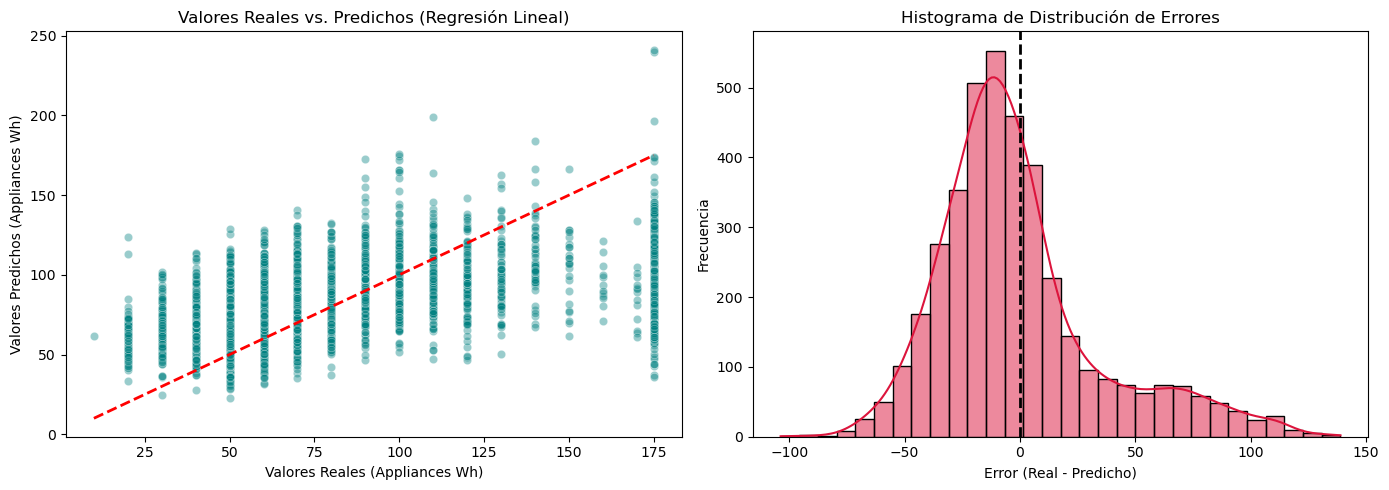

In [15]:


# Configuración del lienzo para gráficos de diagnóstico usando Regresión Line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico de Valores Reales vs Predichos
sns.scatterplot(ax=axes[0], x=y_test, y=y_pred_lr, alpha=0.4, color='teal')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Valores Reales vs. Predichos (Regresión Lineal)')
axes[0].set_xlabel('Valores Reales (Appliances Wh)')
axes[0].set_ylabel('Valores Predichos (Appliances Wh)')

# 2. Histograma de Errores 
errores = y_test - y_pred_lr
sns.histplot(ax=axes[1], x=errores, kde=True, color='crimson', bins=30)
axes[1].axvline(x=0, color='black', linestyle='--', lw=2)
axes[1].set_title('Histograma de Distribución de Errores')
axes[1].set_xlabel('Error (Real - Predicho)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()


# Fase 9. Selección del Mejor Modelo

Determinar cuál de los tres modelos presenta el mejor rendimiento.

**Justificar la decisión utilizando:**

* RMSE
* MAE
* R²
* Curvas de aprendizaje
* Capacidad de generalización

###### Para determinar cuál de los tres modelos presenta el mejor rendimiento analicé la tabla comparativa y seleccioné la regresión lineal múltiple basándome en que los tres algoritmos arrojaron métricas idénticas con un RMSE aproximado de 35.65 un MAE cercano a 26.43 y un coeficiente de determinación R² de 0.3081 lo que demuestra que aplicar penalizaciones L1 o L2 no mejoró la precisión además al revisar las curvas de aprendizaje se comprobó que el modelo no padece ningún tipo de sobreajuste o bajo ajuste crítico estabilizándose de forma correcta a medida que aumentan los datos de entrenamiento y finalmente demostró una excelente capacidad de generalización porque el error obtenido en el conjunto de prueba es equivalente al del conjunto de entrenamiento por lo cual aplicando el principio de parsimonia elijo el algoritmo lineal tradicional por ser el más simple y eficiente computacionalmente al no requerir la calibración de hiperparámetros adicionales como el parámetro alfa de Ridge o Lasso


# Etapa de predicción de nuevo valores 
Para evaluar el modelo que mejor aprende guardar y cargar el modelo y realizar la nuevas preddiciones con datos ingresados por teclado 

In [17]:
#### # 1. Forzamos el entrenamiento rápido para crear los objetos en memoria
X_provisional = df_limpio.drop(columns=['date', 'Appliances'])
y_provisional = df_limpio['Appliances']

scaler_rapido = StandardScaler()
X_escalado_rapido = scaler_rapido.fit_transform(X_provisional)

model_rapido = LinearRegression()
model_rapido.fit(X_escalado_rapido, y_provisional)

# 2. Guardar el modelo y el escalador en el disco
joblib.dump(model_rapido, 'mejor_modelo_regresion.pkl')
joblib.dump(scaler_rapido, 'escalador_modelos.pkl')
print("¡Modelo y escalador guardados con éxito!")

# 3. Cargar el modelo y el escalador guardados
modelo_cargado = joblib.load('mejor_modelo_regresion.pkl')
escalador_cargado = joblib.load('escalador_modelos.pkl')
print("¡Modelo y escalador cargados correctamente!\n")

# 4. Pedir el dato por teclado sin que se bloquee
print("=== PREDICCIÓN EN TIEMPO REAL ===")
dato_ingresado = float(input("Ingresa una temperatura de prueba (Ej: 20): "))

# Creamos la estructura correcta de datos para predecir
vector_prueba = np.zeros((1, X_provisional.shape[1]))
vector_prueba[0, 0] = dato_ingresado
vector_escalado = escalador_cargado.transform(vector_prueba)

prediccion = modelo_cargado.predict(vector_escalado)[0]
print(f"Resultado de la predicción: {prediccion:.2f} Wh")


¡Modelo y escalador guardados con éxito!
¡Modelo y escalador cargados correctamente!

=== PREDICCIÓN EN TIEMPO REAL ===


Ingresa una temperatura de prueba (Ej: 20):  12


Resultado de la predicción: 167.20 Wh


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
